# Введение
## Цель
Исследование методов анализа ассоциативных правил.
## Задачи
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ). Данные должны представлять собой информацию о купленных вместе товарах .
2. Привести описание данных из датасета: график вывода длин транзакций, список уникальных товаров и др. 
3. Алгоритм Apriori: выполнить анализ ассоциативных правил при помощи алгоритма Apriori с изначальными условиями в соответствии с вариантом задания. Проанализировать полученные результаты, выделив полезные и тривиальные правила, и оценив значение достоверности, лифта правил. Провести оценку влияния параметров алгоритма на получаемые правила (на количество правил и метрики).
4. Алгоритм FPG: провести анализ правил, используя алгоритм FPG. В отчете привести правила, получившиеся в результате использования данного алгоритма.
5. Алгоритмически определить минимальные значения поддержки для составления правил из 1, 2, и т.д. объектов в одном из алгоритмов.
6. Последовательно меняя параметры (значения поддержки и достоверности) одного из алгоритмов получить наборы ассоциативных правил. Сделать выводы на основе проведенных экспериментов.
7. Проанализировать получающийся в результате работы программы граф. Объяснить, какую информацию можно из него извлечь.
8. Предложить и реализовать свой способ визуализации ассоциативных правил и метрик.

# Анализ данных
## Описание датасета
Для работы предоставлен датасет [Online Retail Data Set from ML Repository](https://www.kaggle.com/datasets/mathchi/online-retail-data-set-from-ml-repository). 
Начальные параметры для обоих алгоритмов: поддержка 0.15 и достоверность 0.4. 

Этот набор данных содержит реальные транзакции онлайн-ритейлера, базирующегося в Великобритании. Компания работает без физических магазинов (non-store) и специализируется на продаже уникальных подарков на все случаи жизни. Значительная часть клиентской базы — оптовые покупатели. Данные охватывают все транзакции за период с 01 декабря 2010 года по 09 декабря 2011 года.

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from mlxtend.preprocessing import TransactionEncoder
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import numpy as np

file_path = "retail_dataset.csv"

all_data = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "mathchi/online-retail-data-set-from-ml-repository",
  file_path,
)

display(all_data.head())

,0,1,2,3,4,5,6
0,Bread,Wine,Eggs,Meat,Cheese,Pencil,Diaper
1,Bread,Cheese,Meat,Diaper,Wine,Milk,Pencil
2,Cheese,Meat,Eggs,Milk,Wine,NaN,NaN
3,Cheese,Meat,Eggs,Milk,Wine,NaN,NaN
4,Meat,Pencil,Wine,NaN,NaN,NaN,NaN


## График вывода транзакций

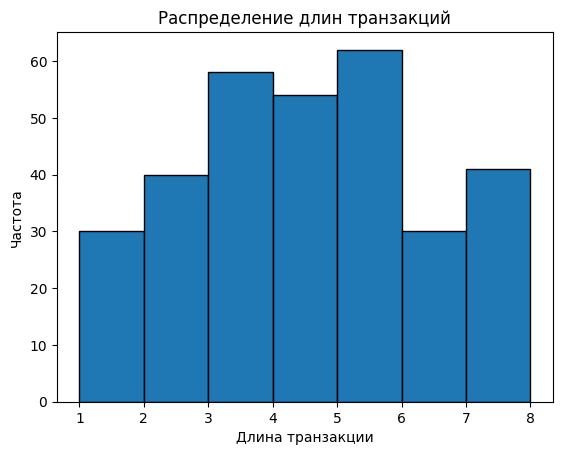

In [118]:
transaction_lengths = all_data.notnull().sum(axis=1)
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2), edgecolor='black')
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()

## График уникальных товаров

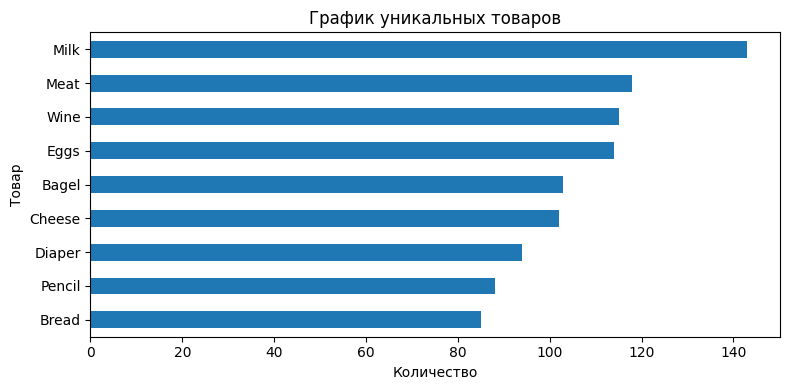

In [119]:
#Очистка данных
np_data = all_data.to_numpy()
np_data = [[elem for elem in row[1:] if isinstance(elem,str)] for row in np_data]
#Список уникальных товаров
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)

te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

item_counts = pd.Series([item for row in np_data for item in row]).value_counts().sort_values()

plt.figure(figsize=(8, 4))
item_counts.plot(kind='barh')
plt.title('График уникальных товаров')
plt.xlabel('Количество')
plt.ylabel('Товар')
plt.tight_layout()
plt.show()

# Ход работы
## 1. Алгоритм Apriori
Начальные параметры: поддержка 0.15 и достоверность 0.4. 

In [120]:
min_support=0.15
min_threshold = 0.4

df_apriori = apriori(data, min_support=min_support, use_colnames = True)
display(df_apriori)
rules_apriori = association_rules(df_apriori, metric = "confidence", min_threshold = min_threshold)
display(rules_apriori)

,support,itemsets
0,0.326984,(Bagel)
1,0.269841,(Bread)
2,0.323810,(Cheese)
3,0.298413,(Diaper)
4,0.361905,(Eggs)
5,0.374603,(Meat)
6,0.453968,(Milk)
7,0.279365,(Pencil)
8,0.365079,(Wine)
9,0.158730,"(Milk, Bagel)"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Bagel),(Milk),0.326984,0.453968,0.158730,0.485437,1.069319,1.0,0.010290,1.061156,0.096321,0.255102,0.057632,0.417544
1,(Wine),(Diaper),0.365079,0.298413,0.158730,0.434783,1.456984,1.0,0.049786,1.241270,0.494000,0.314465,0.194373,0.483349
2,(Diaper),(Wine),0.298413,0.365079,0.158730,0.531915,1.456984,1.0,0.049786,1.356421,0.447059,0.314465,0.262766,0.483349
3,(Meat),(Eggs),0.374603,0.361905,0.215873,0.576271,1.592328,1.0,0.080302,1.505905,0.594804,0.414634,0.335947,0.586381
4,(Eggs),(Meat),0.361905,0.374603,0.215873,0.596491,1.592328,1.0,0.080302,1.549896,0.582968,0.414634,0.354796,0.586381
5,(Eggs),(Milk),0.361905,0.453968,0.212698,0.587719,1.294626,1.0,0.048405,1.324417,0.356650,0.352632,0.244951,0.528125
6,(Milk),(Eggs),0.453968,0.361905,0.212698,0.468531,1.294626,1.0,0.048405,1.200627,0.416782,0.352632,0.167102,0.528125
7,(Wine),(Eggs),0.365079,0.361905,0.180952,0.495652,1.369565,1.0,0.048828,1.265189,0.425000,0.331395,0.209604,0.497826
8,(Eggs),(Wine),0.361905,0.365079,0.180952,0.500000,1.369565,1.0,0.048828,1.269841,0.422886,0.331395,0.212500,0.497826
9,(Meat),(Milk),0.374603,0.453968,0.209524,0.559322,1.232073,1.0,0.039466,1.239072,0.301184,0.338462,0.192944,0.510430


### Формулы для расчета параметров
1. Support (поддержка). Показывает, насколько часто встречается данная комбинация товаров. Чем выше support, тем более типичное правило (но может быть тривиальным).

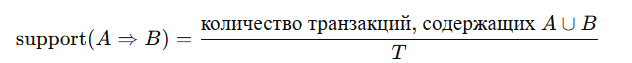

2. Confidence (достоверность). Это условная вероятность: вероятность того, что купят B, если купили A. Однако высокая confidence не гарантирует реальную зависимость — она может быть следствием того, что B просто популярен

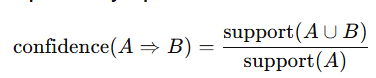

3. Lift (подъём, мера зависимости). Показывает во сколько раз вероятность покупки B возрастает при наличии A.
- lift = 1 — A и B независимы;
- lift > 1 — A и B взаимосвязаны положительно;
- lift < 1 — обратная зависимость (A снижает вероятность B).

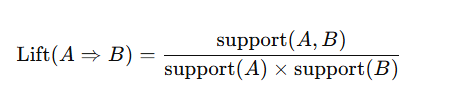


### Анализ правил
Правило можно назвать полезным, если его conf > 0.5 (это будет значит что A и B покупают чаще вместе, чем просто A), но если значение lift будет меньше и близко к 1, то правило будет тривиальным.
По сути это будет значит что это просто популярные товары (которые одинаково часто берут как и вместе и так и по отдельнсти). Среди наших правил можно сделать следующие выводы:

|Правило|confidence|lift|Вывод|
|-|-|-|-|
|Diaper -> Wine	       |0.53|1.46|Тривиальное правило|
|Eggs -> Milk	       |0.59|1.29|Тривиальное правило|
|Wine -> Eggs	       |0.50|1.37|Тривиальное правило|
|Eggs -> Wine	       |0.50|1.37|Тривиальное правило|
|Meat -> Milk	       |0.56|1.23|Тривиальное правило|
|Meat -> Eggs	       |0.58|1.59|Полезное правило|
|Eggs -> Meat	       |0.60|1.59|Полезное правило|
|Wine -> Meat	       |0.56|1.49|Полезное правило|
|Meat -> Wine	       |0.54|1.49|Полезное правило|
|Meat, Eggs -> Milk	   |0.72|1.59|Полезное правило|
|Meat, Milk -> Eggs	   |0.74|2.05|Полезное правило|
|Eggs, Milk -> Meat	   |0.73|1.95|Полезное правило|


По сути самыми полезными правилами можно назвать покупку Meat, Eggs, Milk во всех вариациях. Их часто берут вместе.

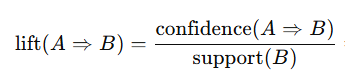

### График поддержки для продуктов

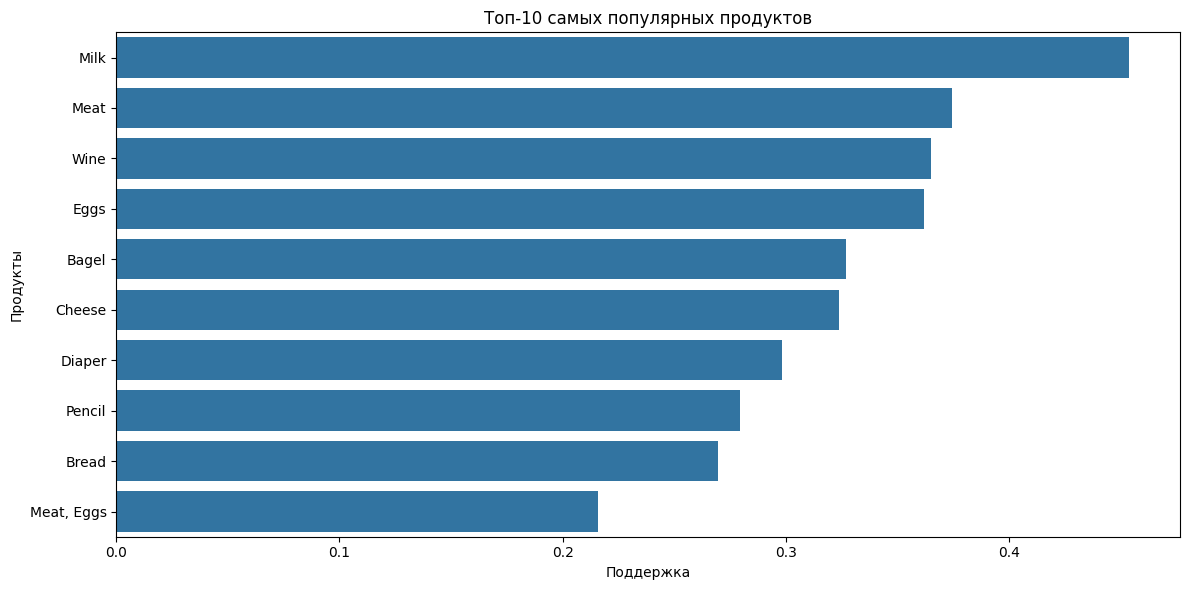

In [121]:
df_apriori['itemsets'] = df_apriori['itemsets'].apply(lambda x: ', '.join(list(x)))
top_products = df_apriori.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()
rules_apriori['antecedents'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_apriori['consequents'] = rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)))

### График достоверности используемых правил

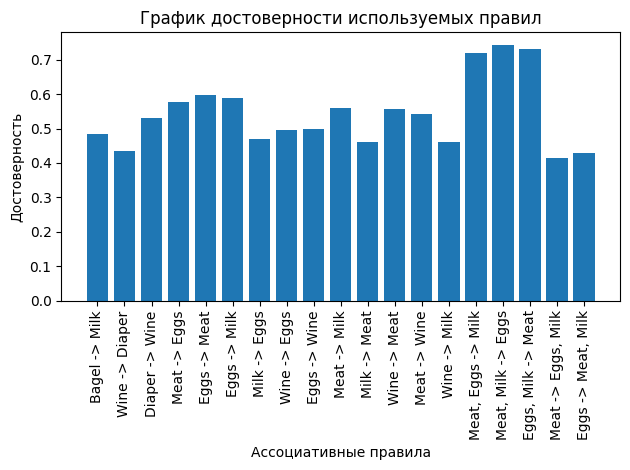

In [122]:
products_1 = rules_apriori["antecedents"].tolist()
products_2 = rules_apriori["consequents"].tolist()
confidence = rules_apriori["confidence"].tolist()
rules_apriori_labels = [f"{product1} -> {product2}" for product1, product2 in zip(products_1, products_2)]

plt.bar(rules_apriori_labels, confidence)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность")
plt.title("График достоверности используемых правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Визуализация ассоциативных правил в виде графа

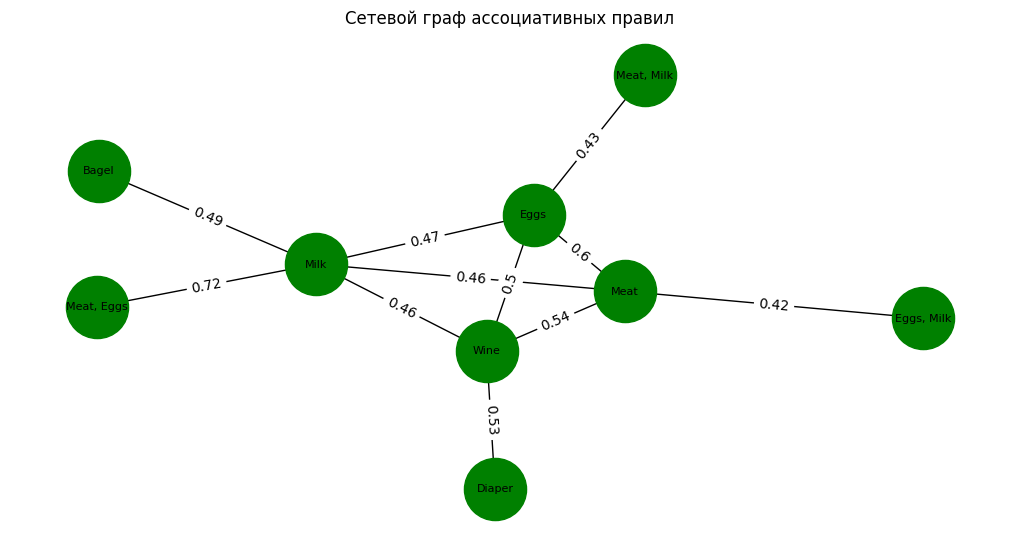

In [123]:
G = nx.Graph()
for product in rules_apriori["antecedents"]:
    G.add_node(product)
for product in rules_apriori["consequents"]:
    G.add_node(product)
for index, row in rules_apriori.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])

pos = nx.spring_layout(G)
plt.figure(figsize=(10, 5))
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='green', font_size=8)
edge_labels = {k: round(v, 2) for k, v in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title('Сетевой граф ассоциативных правил')
plt.show()

По графу можно легко визульно определить, то что Milk, Meat, Eggs часто учавствует в правилах. А например Diaper, Bagel не так часто.

## 2. Алгоритм FPG
Начальные параметры: поддержка 0.15 и достоверность 0.4. 

In [124]:
min_support=0.15
min_threshold = 0.4

df_fpg = fpgrowth(data, min_support=min_support, use_colnames = True)
display(df_fpg)
rules_fpg = association_rules(df_fpg, metric = "confidence", min_threshold = min_threshold)
display(rules_fpg)

,support,itemsets
0,0.374603,(Meat)
1,0.365079,(Wine)
2,0.361905,(Eggs)
3,0.323810,(Cheese)
4,0.298413,(Diaper)
5,0.279365,(Pencil)
6,0.453968,(Milk)
7,0.326984,(Bagel)
8,0.269841,(Bread)
9,0.209524,"(Meat, Milk)"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Meat),(Milk),0.374603,0.453968,0.209524,0.559322,1.232073,1.0,0.039466,1.239072,0.301184,0.338462,0.192944,0.510430
1,(Milk),(Meat),0.453968,0.374603,0.209524,0.461538,1.232073,1.0,0.039466,1.161451,0.344961,0.338462,0.139008,0.510430
2,(Wine),(Meat),0.365079,0.374603,0.203175,0.556522,1.485630,1.0,0.066415,1.410209,0.514844,0.378698,0.290885,0.549447
3,(Meat),(Wine),0.374603,0.365079,0.203175,0.542373,1.485630,1.0,0.066415,1.387419,0.522684,0.378698,0.279237,0.549447
4,(Wine),(Milk),0.365079,0.453968,0.168254,0.460870,1.015202,1.0,0.002520,1.012801,0.023585,0.258537,0.012639,0.415749
5,(Meat),(Eggs),0.374603,0.361905,0.215873,0.576271,1.592328,1.0,0.080302,1.505905,0.594804,0.414634,0.335947,0.586381
6,(Eggs),(Meat),0.361905,0.374603,0.215873,0.596491,1.592328,1.0,0.080302,1.549896,0.582968,0.414634,0.354796,0.586381
7,(Wine),(Eggs),0.365079,0.361905,0.180952,0.495652,1.369565,1.0,0.048828,1.265189,0.425000,0.331395,0.209604,0.497826
8,(Eggs),(Wine),0.361905,0.365079,0.180952,0.500000,1.369565,1.0,0.048828,1.269841,0.422886,0.331395,0.212500,0.497826
9,(Eggs),(Milk),0.361905,0.453968,0.212698,0.587719,1.294626,1.0,0.048405,1.324417,0.356650,0.352632,0.244951,0.528125


### График поддержки для продуктов

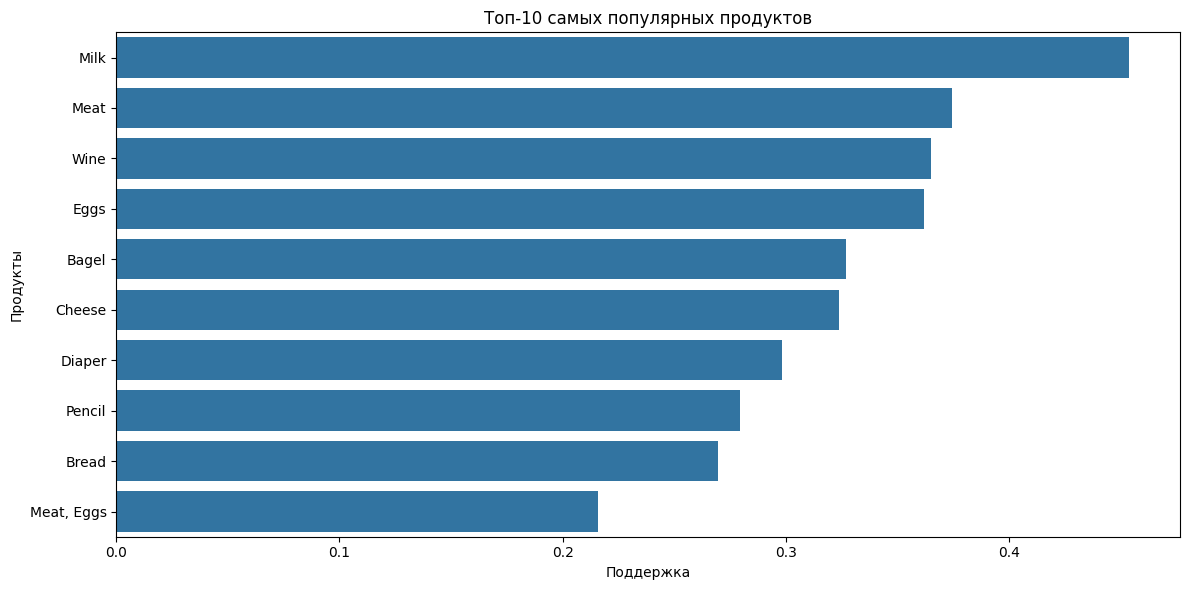

In [125]:
df_fpg['itemsets'] = df_fpg['itemsets'].apply(lambda x: ', '.join(list(x)))
top_products = df_fpg.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()
rules_fpg['antecedents'] = rules_fpg['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_fpg['consequents'] = rules_fpg['consequents'].apply(lambda x: ', '.join(list(x)))

### График достоверности используемых правил

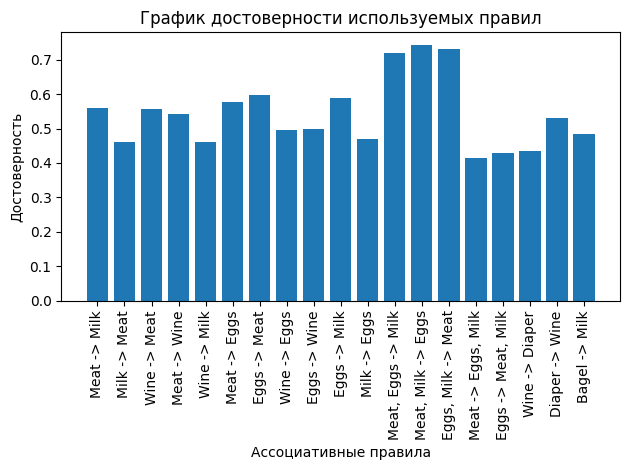

In [126]:
products_1 = rules_fpg["antecedents"].tolist()
products_2 = rules_fpg["consequents"].tolist()
confidence = rules_fpg["confidence"].tolist()
rules_fpg_labels = [f"{product1} -> {product2}" for product1, product2 in zip(products_1, products_2)]

plt.bar(rules_fpg_labels, confidence)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность")
plt.title("График достоверности используемых правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Визуализация ассоциативных правил в виде графа

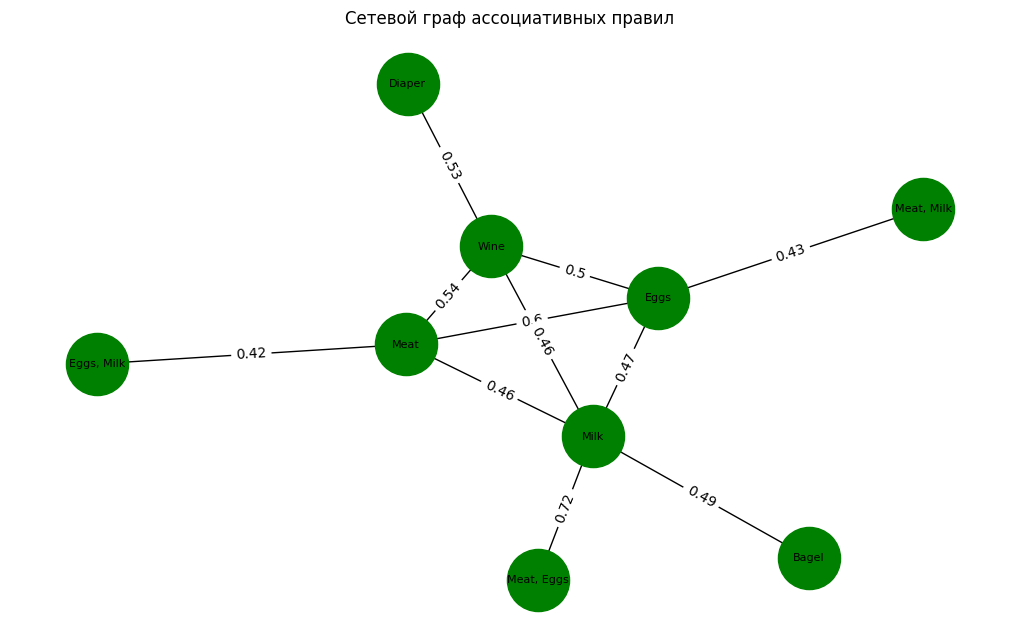

In [127]:
G = nx.Graph()
for product in rules_fpg["antecedents"]:
    G.add_node(product)
for product in rules_fpg["consequents"]:
    G.add_node(product)
for index, row in rules_fpg.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])

pos = nx.spring_layout(G)
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='green', font_size=8)
edge_labels = {k: round(v, 2) for k, v in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title('Сетевой граф ассоциативных правил')
plt.show()

## 3. Эсперементы с алгоритмом Apriori

### Определение минимальных значений поддержки для составления правил из 1, 2 и т.д. объектов

In [ ]:
supports = np.arange(0.001, 0.51, 0.001) 
results = []


for s in supports:
    itemsets = apriori(data, min_support=s, use_colnames=True)
    if not itemsets.empty:
        max_len = itemsets['itemsets'].apply(len).max()
        results.append((s, max_len, len(itemsets)))

df_support_analysis = pd.DataFrame(results, columns=['min_support', 'max_len', 'num_itemsets'])
df_unique_max_len = df_support_analysis.loc[df_support_analysis.groupby('max_len')['min_support'].idxmin()]

df_unique_max_len = df_unique_max_len.sort_values('max_len', ascending=False).reset_index(drop=True)

display(df_unique_max_len)

,min_support,max_len,num_itemsets
0,0.001,6,370
1,0.016,5,210
2,0.026,4,158
3,0.074,3,52
4,0.156,2,17
5,0.216,1,9


### Последовательная смена поддержки и достоверности 

In [ ]:

experiments = [
    {'min_support': 0.15, 'min_threshold': 0.40, 'label': 'Базовый вариант'},
    {'min_support': 0.10, 'min_threshold': 0.40, 'label': 'Уменьшена поддержка'},
    {'min_support': 0.20, 'min_threshold': 0.40, 'label': 'Увеличена поддержка'},
    {'min_support': 0.15, 'min_threshold': 0.20, 'label': 'Уменьшена достоверность'},
    {'min_support': 0.15, 'min_threshold': 0.60, 'label': 'Увеличена достоверность'},
    {'min_support': 0.20, 'min_threshold': 0.45, 'label': 'Увеличены оба параметра'},
    {'min_support': 0.10, 'min_threshold': 0.20, 'label': 'Уменьшены оба параметра'},
]

results = []

for exp in experiments:
    df_apriori = apriori(data, min_support=exp['min_support'], use_colnames=True)
    rules = association_rules(df_apriori, metric="confidence", min_threshold=exp['min_threshold'])
    
    results.append({
        'Вариант': exp['label'],
        'min_support': exp['min_support'],
        'min_confidence': exp['min_threshold'],
        'Количество правил': len(rules),
        'Средний support': round(rules['support'].mean(), 3) if not rules.empty else 0,
        'Средний confidence': round(rules['confidence'].mean(), 3) if not rules.empty else 0,
        'Средний lift': round(rules['lift'].mean(), 3) if not rules.empty else 0
    })

df_results = pd.DataFrame(results)
display(df_results)

,Вариант,min_support,min_confidence,Количество правил,Средний support,Средний confidence,Средний lift
0,Базовый вариант,0.15,0.40,19,0.182,0.542,1.502
1,Уменьшена поддержка,0.10,0.40,45,0.151,0.500,1.387
2,Увеличена поддержка,0.20,0.40,8,0.210,0.544,1.401
3,Уменьшена достоверность,0.15,0.20,22,0.180,0.516,1.464
4,Увеличена достоверность,0.15,0.60,3,0.156,0.731,1.864
5,Увеличены оба параметра,0.20,0.45,8,0.210,0.544,1.401
6,Уменьшены оба параметра,0.10,0.20,80,0.137,0.424,1.290


- При низких порогах поддержки и достоверности алгоритм генерирует много слабых и тривиальных правил.
- При высоких порогах остаются немногочисленные, но информативные правила с высоким лифтом.

### Bubble chart

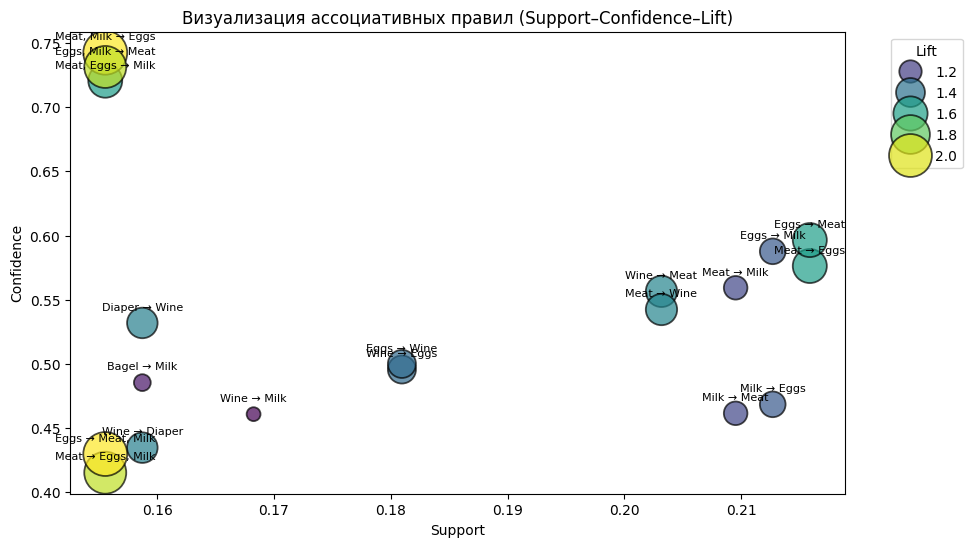

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

min_support=0.15
min_threshold = 0.4

df_apriori = apriori(data, min_support=min_support, use_colnames = True)
rules_viz = association_rules(df_apriori, metric = "confidence", min_threshold = min_threshold)

rules_viz['antecedents'] = rules_viz['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_viz['consequents'] = rules_viz['consequents'].apply(lambda x: ', '.join(list(x)))
rules_viz['rule'] = rules_viz['antecedents'] + " → " + rules_viz['consequents']

plt.figure(figsize=(10, 6))
bubble = sns.scatterplot(
    data=rules_viz,
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    sizes=(100, 1000),
    palette='viridis',
    alpha=0.7,
    edgecolor='black'
)

for i in range(len(rules_viz)):
    plt.text(
        rules_viz['support'].iloc[i],
        rules_viz['confidence'].iloc[i] + 0.01,
        rules_viz['rule'].iloc[i],
        fontsize=8,
        ha='center'
    )

plt.title('Визуализация ассоциативных правил (Support–Confidence–Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Выводы

В ходе работы проведён анализ транзакционных данных с использованием алгоритмов Apriori и FPG для выявления ассоциативных правил между товарами. Были получены правила с различными метриками (support, confidence, lift), выявлены как полезные устойчивые закономерности, так и менее значимые тривиальные правила. Проведён анализ влияния параметров поддержки и достоверности: снижение порогов увеличивает количество правил, но снижает их качество, повышение — наоборот. Визуализация правил через сетевой граф и пузырьковую диаграмму позволила наглядно определить ключевые товары и сильные ассоциации. 